In [49]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code


In [50]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 8,
        "figure.titlesize": 14,
        "pdf.fonttype": 42,
    }
)

In [51]:
# other imports
import numpy as np
from importlib import reload

## Exp. Design
Write some text about experimental design

## Performance Metrics

#### Learning
Start simple, lets look at trials across learning between conditions & in expert behaviour (when stim starts)

In [4]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

maze order: 1
Learning stats:
                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      total_trials
No. Observations:       135          Method:                  ML          
No. Groups:             15           Scale:                   259.5240    
Min. group size:        9            Log-Likelihood:          -582.9639   
Max. group size:        9            Converged:               Yes         
Mean group size:        9.0                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      26.569    6.686  3.974 0.000  13.464 39.675
condition[T.opto]              -3.887    9.788 -0.397 0.691 -23.071 15.297
day_on_maze                     8.667    0.735 11.786 0.000   7.225 10.108
condition[T.op

Expert performance stats:
random effects t-test: t=1.48, p=0.162
maze order: 2
Learning stats:
                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      total_trials
No. Observations:       75           Method:                  ML          
No. Groups:             15           Scale:                   198.2904    
Min. group size:        5            Log-Likelihood:          -319.4738   
Max. group size:        5            Converged:               Yes         
Mean group size:        5.0                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      28.525    7.579  3.764 0.000  13.670 43.380
condition[T.opto]              -8.511   11.095 -0.767 0.443 -30.257 13.235
day_on_maze             

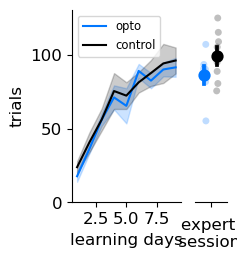

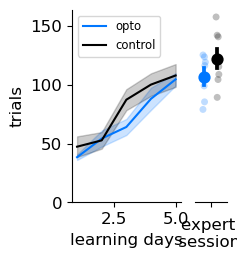

In [43]:
reload(bl)
for maze_order in [1, 2]:
    print(f"maze order: {maze_order}")
    fig, axes = plt.subplots(1, 2, figsize=(2, 2.5), width_ratios=[1, 0.3], sharey=True)
    bl.plot_performance_summary(learning_df, expert_df, maze_order=maze_order, print_stats=True, axes=axes)
    fig.savefig(f"../results/figures/learning_maze_order_{maze_order}.pdf")

#### Excess steps (during expert behaviour with mFC inhibition)

In [3]:
from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.core import plotting as cp

performance_df = pm.get_performance_df()

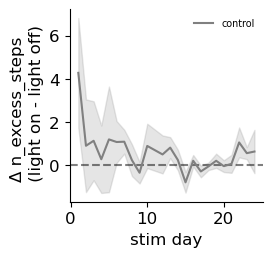

In [46]:
reload(pm)
f, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
pm.plot_stim_effects_over_days(
    performance_df,
    y="n_excess_steps",
    groups=["control"],
    rolling_avg=False,
    ax=ax,
)

Mixed ANOVA: trial_duration
+-------------+-------------+-------+-------+-------------+------------+----------+-------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |          F |    p-unc |         np2 |   eps |
|-------------+-------------+-------+-------+-------------+------------+----------+-------------+-------|
| condition   | 24.5156     |     1 |    13 | 24.5156     | 1.25059    | 0.283679 | 0.0877573   |   nan |
| stim_trial  |  0.00136272 |     1 |    13 |  0.00136272 | 0.00112905 | 0.973705 | 8.68425e-05 |     1 |
| Interaction |  1.89795    |     1 |    13 |  1.89795    | 1.5725     | 0.231925 | 0.107909    |   nan |
+-------------+-------------+-------+-------+-------------+------------+----------+-------------+-------+
Mixed ANOVA: n_errors
+-------------+-------------+-------+-------+-------------+------------+----------+-------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |          F |    p-unc |         np2 |   ep

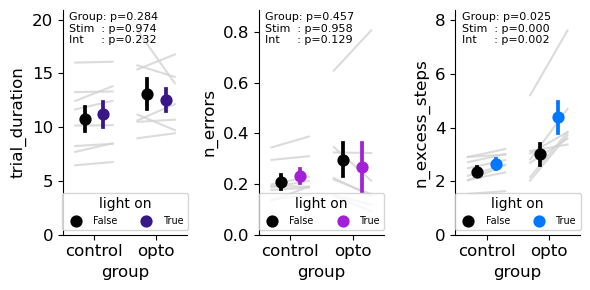

In [50]:
reload(pm)
reload(cp)

fig, axes = plt.subplots(1, 3, figsize=(6, 3))
for y, ax, ot, color in zip(
    ["trial_duration", "n_errors", "n_excess_steps"],
    axes,
    [3 * 60, 15, 500],  # roughly 99.5th percentiles
    ["#381887", "#A220D5", "#0077FF"],
):
    pm.plot_random_effects_summary(
        performance_df,
        y=y,
        stim_day_range=(6, np.inf),
        outlier_thres=ot,
        print_stats=True,
        stim_color=color,
        ax=ax,
    )
fig.tight_layout()
fig.savefig("../results/figures/performance_metrics_summary.pdf")

### Example trajectory plots

In [9]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

session = gs.get_maze_sessions(subject_IDs=["mFC-opto_23"], maze_names=["maze_2"], days_on_maze=[9])[0]

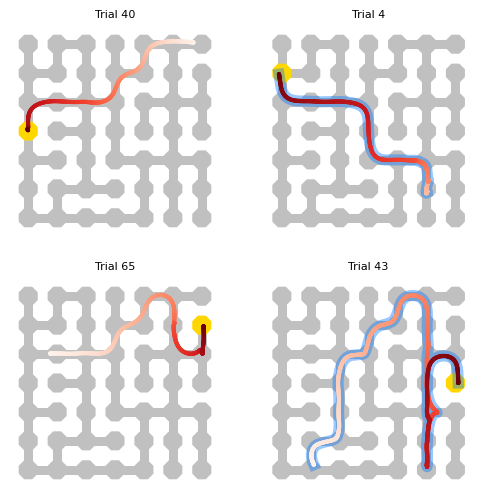

In [51]:
f, axes = plt.subplots(2, 2, figsize=(6, 6))
for ax, t in zip(axes.flatten(), [40, 4, 65, 43]):
    tp.plot_fancy_trial_trajectory(session, trial=t, ax=ax)
f.savefig("../results/figures/opto_trajectory_examples.pdf")

In [52]:
session2 = gs.get_maze_sessions(subject_IDs=["mFC-opto_26"], total_stim_days=[17])[0]

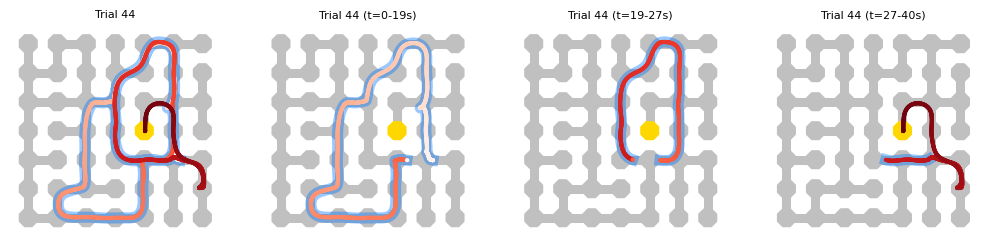

In [53]:
# another example disrupted nav trial in opto subject
reload(tp)
trial = 44
f, axes = plt.subplots(1, 4, figsize=(12.5, 3.5))
for ax, t_range in zip(axes, [None, (0, 19), (19, 27), (27, 40)]):
    tp.plot_fancy_trial_trajectory(session2, trial=trial, t_range=t_range, ax=ax)
f.savefig("../results/figures/opto_trajectory_examples2.pdf")

### Does mFC inhibition impair early navigation?

In [13]:
from GridMaze.analysis.behaviour import distance_to_goal as dtg

ddtg_df = dtg.get_delta_distance_to_goal_df()
curve_fit_results = dtg.get_ddtg_curve_fit_df(ddtg_df, stim_day_range=(6, np.inf))

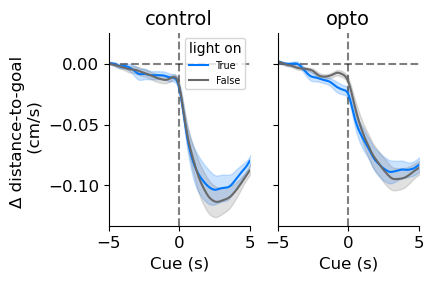

In [56]:
reload(dtg)
f, axes = plt.subplots(1, 2, figsize=(4, 2.5), sharey=True)
dtg.plot_delta_distance_to_goal_summary(ddtg_df, axes=axes)
f.savefig("../results/figures/delta_distance_to_goal_summary.pdf")

Mixed ANOVA: amplitude
+-------------+-------------+-------+-------+-------------+----------+----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |    p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+----------+-----------+-------|
| condition   | 0.0013248   |     1 |    13 | 0.0013248   | 0.778562 | 0.393605 | 0.0565053 |   nan |
| stim_trial  | 0.00193846  |     1 |    13 | 0.00193846  | 8.90566  | 0.010554 | 0.406546  |     1 |
| Interaction | 0.000102329 |     1 |    13 | 0.000102329 | 0.470121 | 0.504976 | 0.034901  |   nan |
+-------------+-------------+-------+-------+-------------+----------+----------+-----------+-------+
Mixed ANOVA: lambda
+-------------+-----------+-------+-------+-----------+----------+-----------+-----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |        F |     p-unc |       np2 |   eps |
|-------------+-----------+-------+-------+--

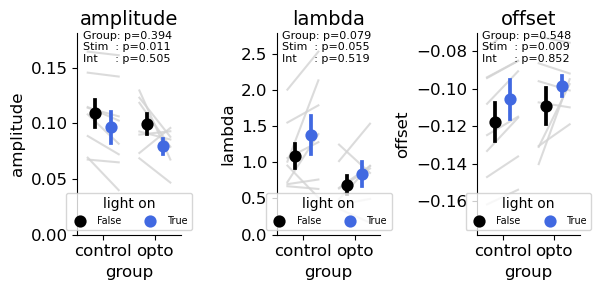

In [120]:
reload(dtg)
fig, axes = plt.subplots(1, 3, figsize=(6, 3))
dtg.plot_curve_fit_random_effects_summary(curve_fit_results, print_stats=True, axes=axes)
fig.tight_layout()
fig.savefig("../results/figures/ddtg_curve_fit_summary.pdf")

prelim conclusion: no obvious differences at the start of the trial, mFC less important here

### Is the group x stim effect equally strong on all trials or does it interact with maze structure / starting distance to goal, etc.

In [4]:
from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.behaviour import excess_steps as es

excess_steps_df = pm.get_performance_df()

### Additional excess steps in the opto group is not evenly spread across navigational goals...

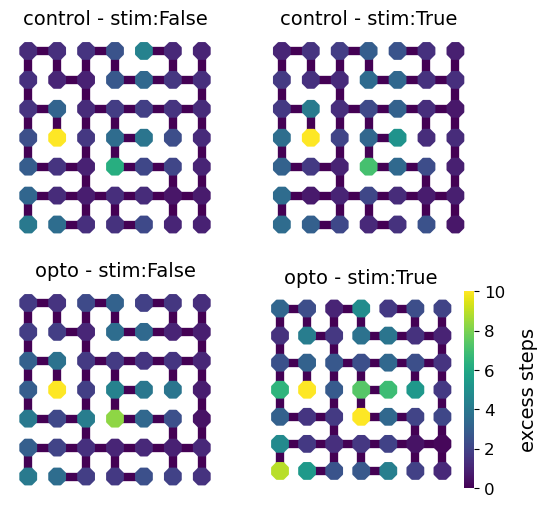

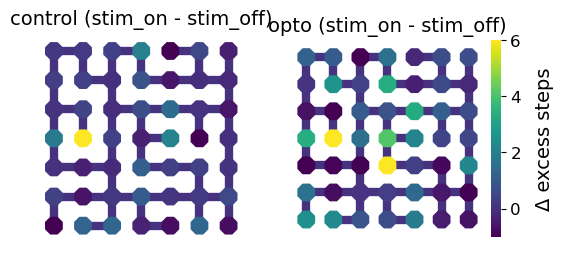

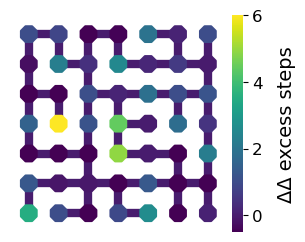

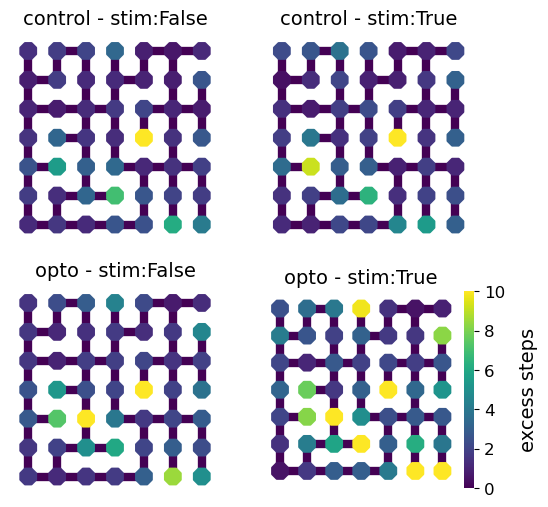

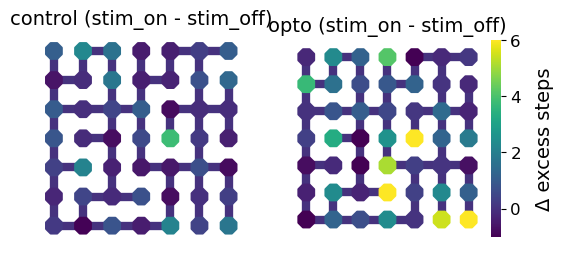

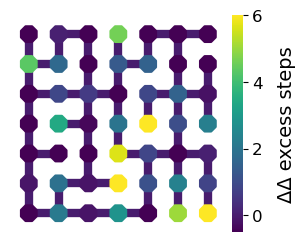

In [46]:
reload(es)
for maze in ["maze_1", "maze_2"]:
    f1, axes1 = plt.subplots(2, 2, figsize=(6, 6))
    f2, axes2 = plt.subplots(1, 2, figsize=(6, 3))
    f3, axes3 = plt.subplots(1, 1, figsize=(3, 3))
    for pa, v_range, axes in zip(
        ["raw", "delta", "delta_delta"],
        [(None, 10), (-1, 6), (-0.5, 6)],
        [axes1, axes2, axes3],
    ):
        es.plot_excess_steps_by_goal_heatmap_summary(
            excess_steps_df,
            outlier_thres=200,
            maze_name=maze,
            vmin=v_range[0],
            vmax=v_range[1],
            plot_as=pa,
            colormap="viridis",
            axes=axes,
        )
    f1.savefig(f"../results/figures/excess_steps_heatmap_{maze}_summary_raw.pdf")
    f2.savefig(f"../results/figures/excess_steps_heatmap_{maze}_summary_delta.pdf")
    f3.savefig(f"../results/figures/excess_steps_heatmap_{maze}_summary_delta_delta.pdf")

#### Indeed, trials with goals with higher fitness* have stim-induced performance deficits in the opto group
*term borrowed from how we design the mazes: decorrelation between eucldiean and geodesic distances across all pairs of points including a given goal

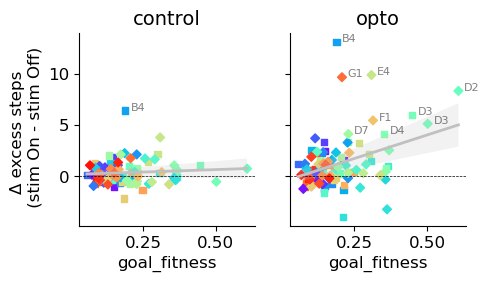

In [16]:
reload(es)
f, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True, sharex=True)
es.plot_stratified_delta_excess_steps(
    excess_steps_df,
    stim_day_range=(6, np.inf),
    outlier_thres=200,
    var="goal_fitness",
    axes=axes,
)
f.savefig("../results/figures/goal_fitness_stratified_delta_excess_steps.pdf")

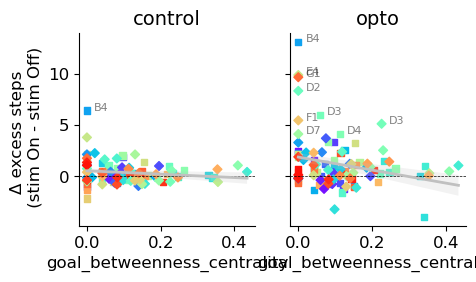

In [18]:
f, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True, sharex=True)
es.plot_stratified_delta_excess_steps(
    excess_steps_df,
    stim_day_range=(6, np.inf),
    outlier_thres=200,
    var="goal_betweenness_centrality",
    axes=axes,
)
f.savefig("../results/figures/goal_betweenness_stratified_delta_excess_steps.pdf")

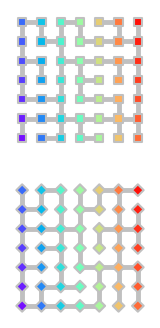

In [70]:
f, axes = plt.subplots(2, 1, figsize=(2, 4))
es.plot_special_maze_legend(axes=axes)
f.savefig("../results/figures/stratified_excess_steps_maze_legend.pdf")

#### we can get a random effects measure on the strength of this effect by comparing the slopes across opto and control conditions

T-tests on slope from delta xs steps linear fit:
  control vs opto: t=-2.30, p=0.038
  control vs 0: t=0.63, p=0.550
  opto vs 0: t=2.70, p=0.035


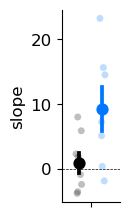

In [19]:
f, ax = plt.subplots(1, 1, figsize=(0.75, 2.5))
es.plot_delta_excess_steps_fit_slopes(
    excess_steps_df, stim_day_range=(6, np.inf), outlier_thres=200, var="goal_fitness", print_stats=True, ax=ax
)
f.savefig("../results/figures/delta_excess_steps_fit_slopes_goal_fitness.pdf")

T-tests on slope from delta xs steps linear fit:
  control vs opto: t=2.00, p=0.067
  control vs 0: t=-1.41, p=0.200
  opto vs 0: t=-2.97, p=0.025


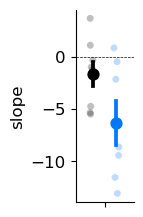

In [20]:
f, ax = plt.subplots(1, 1, figsize=(0.75, 2.5))
es.plot_delta_excess_steps_fit_slopes(
    excess_steps_df,
    stim_day_range=(6, np.inf),
    outlier_thres=200,
    var="goal_betweenness_centrality",
    print_stats=True,
    ax=ax,
)

#### another way to look at this effect is with a comparison linear mixed models, modelling n_excess_steps across trials to test for a specific group x stim x goal_fitness interaction

In [70]:
es.run_3way_linear_mixed_model(
    excess_steps_df,
    stim_day_range=(6, np.inf),
    outlier_thres=None,
    var="goal_fitness",
    zscore_var=True,
    print_stats_model_summaries=True,
)

Likelihood Ratio Test for group x stim x var interaction:
    LR=10.278, df=1, p=0.001346
Full model results:
                              Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             n_excess_steps
No. Observations:              29593               Method:                         ML            
No. Groups:                    15                  Scale:                          69.3264       
Min. group size:               1404                Log-Likelihood:                 -104735.1651  
Max. group size:               2665                Converged:                      Yes           
Mean group size:               1972.9                                                            
-------------------------------------------------------------------------------------------------
                                                         Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------

In [69]:
reload(es)
es.run_double_3_way_linear_mixed_model(
    excess_steps_df,
    outlier_thres=500,
    full_random_effects=False,
)

Fitting full model...
Full model results:
                                   Mixed Linear Model Regression Results
Model:                            MixedLM                 Dependent Variable:                 n_excess_steps
No. Observations:                 29593                   Method:                             ML            
No. Groups:                       15                      Scale:                              68.2642       
Min. group size:                  1404                    Log-Likelihood:                     -104503.1433  
Max. group size:                  2665                    Converged:                          Yes           
Mean group size:                  1972.9                                                                    
------------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------

### What errors do subjects make?

In [52]:
from GridMaze.analysis.errors import errors

error_df = errors.get_error_df()

Mixed ANOVA: error_rate
+-------------+-------------+-------+-------+-------------+----------+-------------+------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |       p-unc |        np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+-------------+------------+-------|
| condition   | 0.000247159 |     1 |    13 | 0.000247159 |  4.87596 | 0.0458059   | 0.272766   |   nan |
| stim_trial  | 0.000245427 |     1 |    13 | 0.000245427 | 18.2186  | 0.000915505 | 0.583581   |     1 |
| Interaction | 1.70614e-06 |     1 |    13 | 1.70614e-06 |  0.12665 | 0.727639    | 0.00964834 |   nan |
+-------------+-------------+-------+-------+-------------+----------+-------------+------------+-------+
Mixed ANOVA: repeat_error_rate
+-------------+-------------+-------+-------+-------------+----------+------------+----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |      p-unc |      np2 |   eps

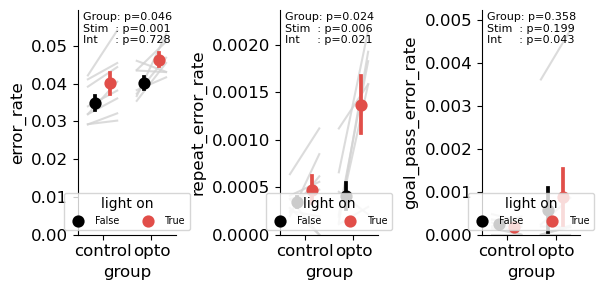

In [110]:
reload(errors)
fig, axes = plt.subplots(1, 3, figsize=(6, 3))
for err_type, ax in zip(["error", "repeat_error", "goal_pass_error"], axes):
    errors.plot_group_by_stim_errors(
        error_df,
        e=err_type,
        stim_color="#E14E49",
        ax=ax,
        print_stats=True,
        legend=True,
    )
fig.tight_layout()
fig.savefig("../results/figures/error_metrics_summary.pdf")

#### another intuition is that with opto stim, subjects are less likely to correct mistakes/errors and continue on habitual paths (not turn around and head back to the goal)

In [21]:
from GridMaze.analysis.errors import correction as corr

In [24]:
reload(corr)
results_df = corr.get_error_centered_df(
    error_df,
    n_jobs=-1,
)

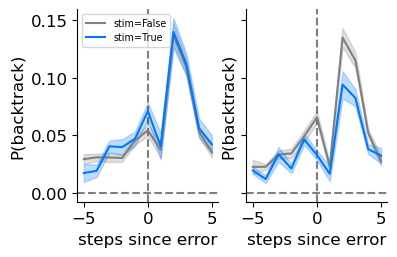

In [25]:
reload(corr)
fig, axes = plt.subplots(1, 2, figsize=(4, 2.5), sharex=True, sharey=True)
corr.plot_prob_backtrack_after_error(results_df, axes=axes)
fig.savefig("../results/figures/prob_backtrack_after_error.pdf")

Mixed ANOVA: prob_backtrack
+-------------+------------+-------+-------+------------+----------+------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |      p-unc |      np2 |   eps |
|-------------+------------+-------+-------+------------+----------+------------+----------+-------|
| condition   | 0.00236122 |     1 |    13 | 0.00236122 | 11.4477  | 0.00489566 | 0.468252 |   nan |
| stim_trial  | 0.00182034 |     1 |    13 | 0.00182034 |  6.93627 | 0.0206425  | 0.347922 |     1 |
| Interaction | 0.00292567 |     1 |    13 | 0.00292567 | 11.1481  | 0.00533365 | 0.461654 |   nan |
+-------------+------------+-------+-------+------------+----------+------------+----------+-------+


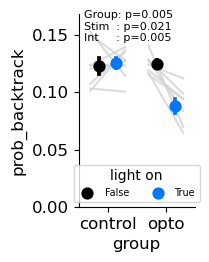

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2.5))
corr.plot_group_by_stim_error_backtrack(results_df, n=[2, 3], ax=ax)
fig.savefig("../results/figures/error_backtrack_summary.pdf")

#### lets also do some stratifaction of errors by distance to goal

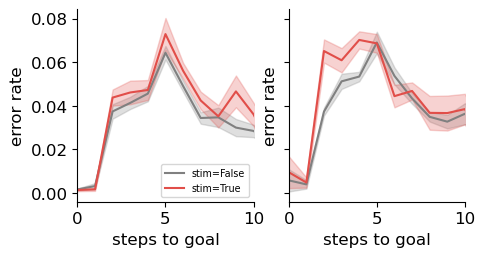

In [79]:
reload(errors)
f, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True)
errors.plot_step_stratifed_error_rate(error_df, max_steps=10, stim_color="#E14E49", axes=axes)
f.savefig("../results/figures/step_stratified_error_rate.pdf")

Mixed ANOVA: error_rate
+-------------+-------------+-------+-------+-------------+---------+-------------+----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |       F |       p-unc |      np2 |   eps |
|-------------+-------------+-------+-------+-------------+---------+-------------+----------+-------|
| condition   | 0.00124294  |     1 |    13 | 0.00124294  | 14.5387 | 0.00215365  | 0.527937 |   nan |
| stim_trial  | 0.000855826 |     1 |    13 | 0.000855826 | 38.3186 | 3.26979e-05 | 0.746681 |     1 |
| Interaction | 0.000352369 |     1 |    13 | 0.000352369 | 15.7769 | 0.00159396  | 0.548249 |   nan |
+-------------+-------------+-------+-------+-------------+---------+-------------+----------+-------+


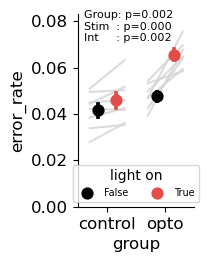

In [ ]:
reload(errors)
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2.5))
errors.plot_group_by_stim_errors(
    error_df,
    e="error",
    steps_to_goal_range=(2, 4),
    stim_color="#E14E49",
    ax=ax,
    print_stats=True,
    legend=True,
)
fig.savefig("../results/figures/short_distance_error_rate_summary.pdf")

### look at where errors occur on maze

In [28]:
from GridMaze.analysis.errors import allocentric_error_maps as am
from importlib import reload

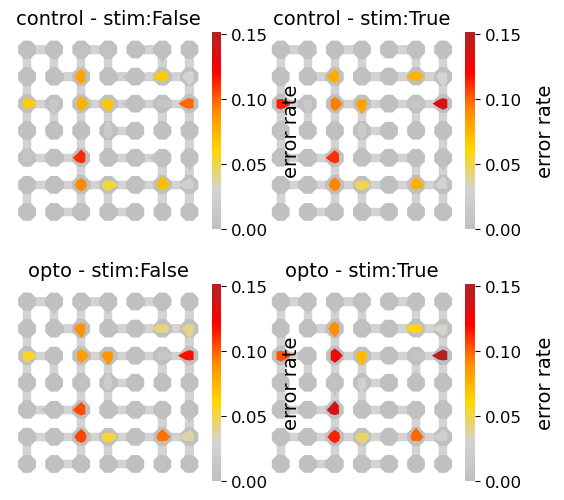

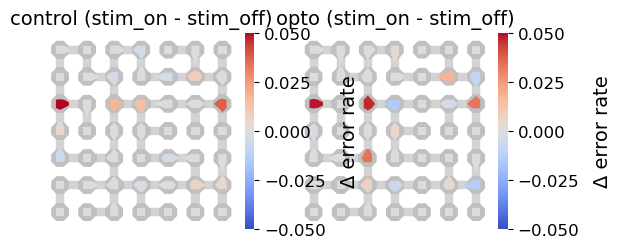

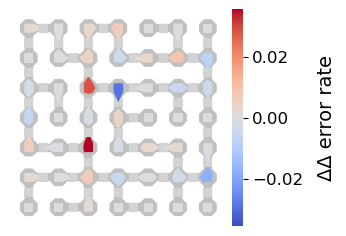

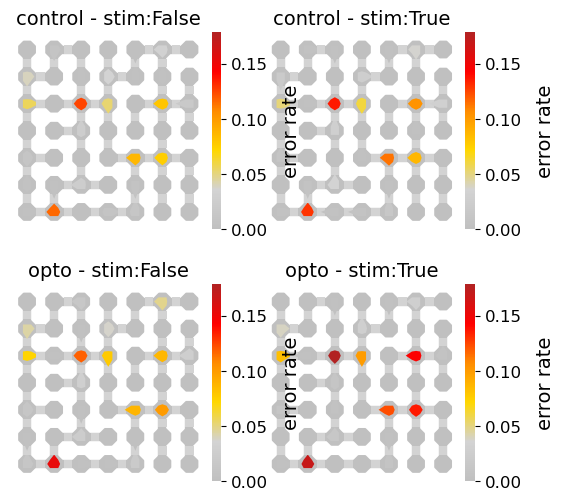

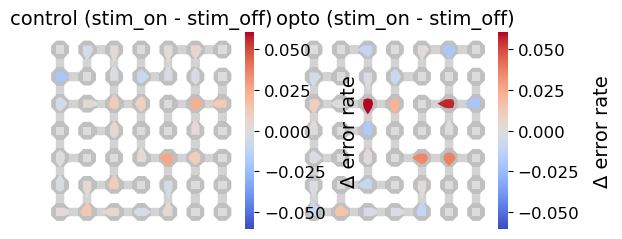

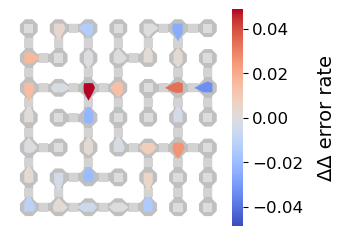

In [87]:
reload(am)
results_df = am.get_allocentric_error_maps_df(error_df, e="error")
for maze in ["maze_1", "maze_2"]:
    f1, axes1 = plt.subplots(2, 2, figsize=(6, 6))
    f2, axes2 = plt.subplots(1, 2, figsize=(6, 3))
    f3, axes3 = plt.subplots(1, 1, figsize=(3, 3))
    for plot_as, colormap, axes in zip(
        ["raw", "delta", "delta_delta"],
        ["heat", "coolwarm", "coolwarm"],
        [axes1, axes2, axes3],
    ):
        am.plot_allocentric_error_map_summary(
            results_df,
            maze_name=maze,
            plot_as=plot_as,
            colormap=colormap,
            axes=axes,
        )
    f1.savefig(f"../results/figures/allocentric_error_map_{maze}_summary_raw.pdf")
    f2.savefig(f"../results/figures/allocentric_error_map_{maze}_summary_delta.pdf")
    f3.savefig(f"../results/figures/allocentric_error_map_{maze}_summary_delta_delta.pdf")

In [ ]:
reload(am)
missed_path_df = am.get_missed_paths_df(error_df, stim_day_range=(6, np.inf))

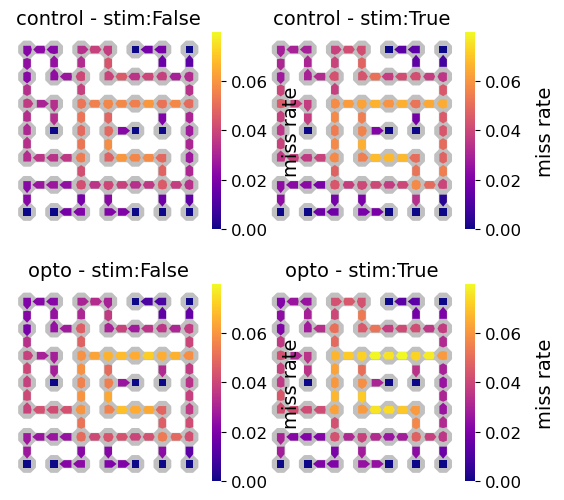

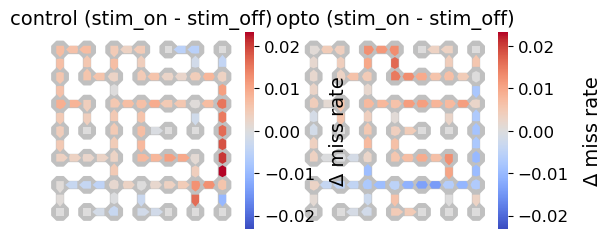

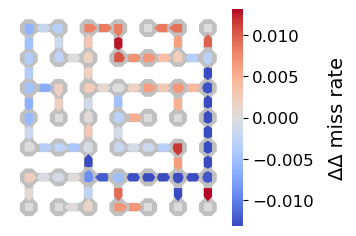

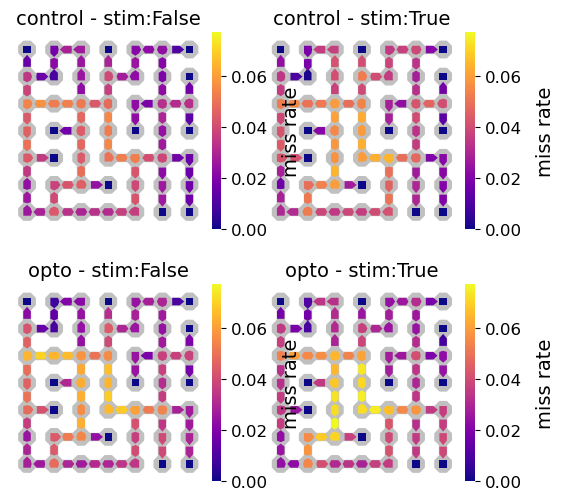

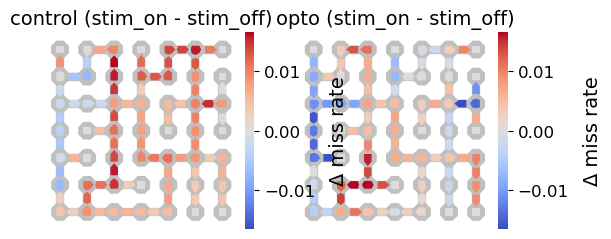

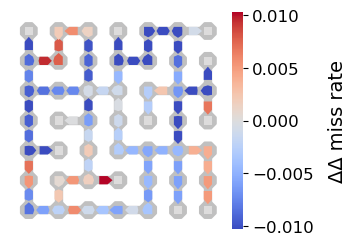

In [32]:
reload(am)
for maze in ["maze_1", "maze_2"]:
    f1, axes1 = plt.subplots(2, 2, figsize=(6, 6))
    f2, axes2 = plt.subplots(1, 2, figsize=(6, 3))
    f3, axes3 = plt.subplots(1, 1, figsize=(3, 3))
    for plot_as, colormap, axes in zip(
        ["raw", "delta", "delta_delta"], ["plasma", "coolwarm", "coolwarm"], [axes1, axes2, axes3]
    ):
        am.plot_missed_paths_summary(
            missed_path_df,
            maze_name=maze,
            plot_as=plot_as,
            colormap=colormap,
            axes=axes,
        )
    f1.savefig(f"../results/figures/missed_paths_{maze}_summary_raw.pdf")
    f2.savefig(f"../results/figures/missed_paths_{maze}_summary_delta.pdf")
    f3.savefig(f"../results/figures/missed_paths_{maze}_summary_delta_delta.pdf")

In [28]:
from GridMaze.analysis.errors import egocentric_error_maps as em

reload(em)
ego_df = em.get_egocentric_error_map_df(error_df, smooth_sigma_levels=(0.0, 1, 2.5))

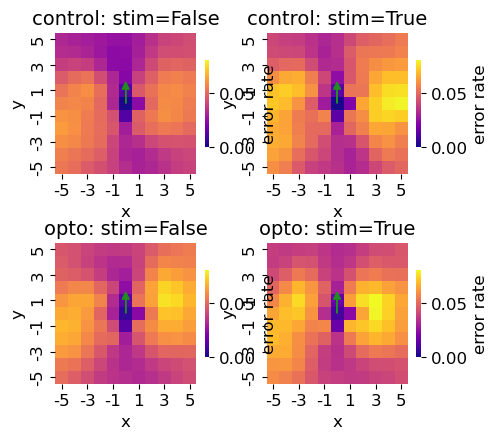

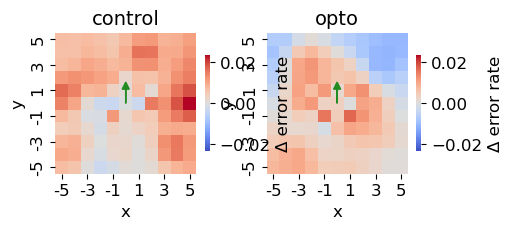

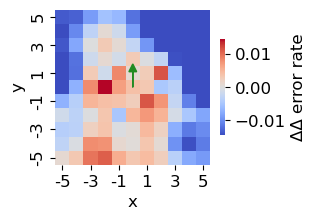

In [91]:
f1, axes1 = plt.subplots(2, 2, figsize=(5, 5))
f2, axes2 = plt.subplots(1, 2, figsize=(5, 2.5))
f3, axes3 = plt.subplots(1, 1, figsize=(2.5, 2.5))
for plt_as, colormap, axes in zip(
    ["raw", "delta", "delta_delta"], ["plasma", "coolwarm", "coolwarm"], [axes1, axes2, axes3]
):
    em.plot_egocentric_error_map_summary(
        ego_df,
        wmax=5,
        plot_as=plt_as,
        colormap=colormap,
        axes=axes,
    )
f1.savefig("../results/figures/egocentric_error_map_summary_raw.pdf")
f2.savefig("../results/figures/egocentric_error_map_summary_delta.pdf")
f3.savefig("../results/figures/egocentric_error_map_summary_delta_delta.pdf")

### what about errors when you have to go against habits?

In [63]:
from GridMaze.analysis.strategies import get_input_data as gid
from GridMaze.analysis.strategies import psychometrics as psy
from GridMaze.analysis.strategies import opto_effects as oe

In [5]:
## aside what histroy length best fits the data to define habits?
strategies = ["vector", "structure", "habit", "backtracking_penalty"]
NLL_df = oe.compare_habit_history_lengths(strategies=strategies, verbose=False)

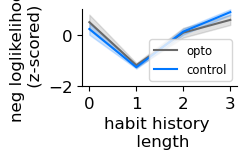

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(2, 1))
oe.plot_history_length_comparison(NLL_df, ax=ax)
ax.set_ylim(-2, 1)
f.savefig("../results/figures/habit_history_length_comparison.pdf")

In [ ]:
reload(gid)
navigation_strategies_df = gid.get_navigation_strategies_df(
    n_history=1,
    verbose=False,
)

Habit value 0.06: group x stim p=0.004
Habit value 0.19: group x stim p=0.005
Habit value 0.31: group x stim p=0.642
Habit value 0.44: group x stim p=0.139
Habit value 0.56: group x stim p=0.955
Habit value 0.69: group x stim p=0.199
Habit value 0.81: group x stim p=0.391
Habit value 0.94: group x stim p=0.233


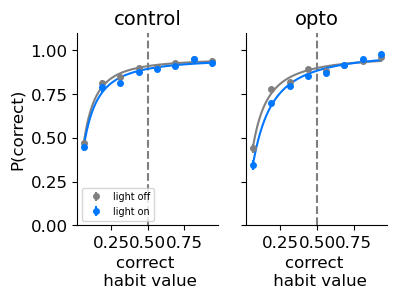

In [53]:
reload(psy)
f, axes = plt.subplots(1, 2, figsize=(4, 2.5), sharey=True, sharex=True)
psy_df = psy.get_psychometrics_df(
    navigation_strategies_df,
    stim_day_range=(6, gs.TOTAL_STIM_DAYS),
    decision_points_only=True,
    x_bins=8,
)
psy.plot_habit_psychometrics_summary(psy_df, fit="log_sigmoid", axes=axes)
f.savefig("../results/figures/habit_psychometrics_summary.pdf")

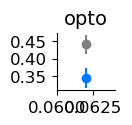

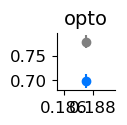

In [ ]:
reload(psy)
for inset_range in [(0.06, 0.064), (0.1855, 0.1895)]:
    f, ax = plt.subplots(1, 1, figsize=(0.75, 0.75))
    psy.plot_habit_psychometrics_inset(psy_df, group="opto", habit_value_range=inset_range, ax=ax)
    f.savefig(f"../results/figures/habit_psychometrics_inset_opto_{inset_range[0]}-{inset_range[1]}.pdf")

Mixed ANOVA: alpha
+-------------+------------+-------+-------+------------+-----------+------------+-----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |         F |      p-unc |       np2 |   eps |
|-------------+------------+-------+-------+------------+-----------+------------+-----------+-------|
| condition   | 0.00161758 |     1 |    13 | 0.00161758 |  0.594122 | 0.454611   | 0.0437043 |   nan |
| stim_trial  | 0.00736132 |     1 |    13 | 0.00736132 | 16.7359   | 0.00127456 | 0.562818  |     1 |
| Interaction | 0.00382251 |     1 |    13 | 0.00382251 |  8.69044  | 0.0113162  | 0.400658  |   nan |
+-------------+------------+-------+-------+------------+-----------+------------+-----------+-------+


Text(-24.234375, 0.5, 'x-shift')

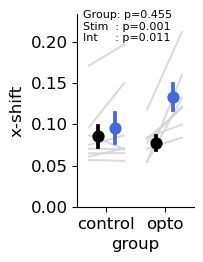

In [90]:
reload(psy)
fit_df = psy.get_curve_fit_df(psy_df, fit="log_sigmoid")
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2.5))
psy.plot_sigmoid_fit_params(fit_df, p=["alpha"], axes=[ax])  # x-shift
fig.savefig("../results/figures/habit_log_sigmoid_fit_params.pdf")
ax.set_ylabel("x-shift")

0.1870424663854708
Mixed ANOVA: prob_correct
+-------------+------------+-------+-------+------------+---------+-------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |       F |       p-unc |      np2 |   eps |
|-------------+------------+-------+-------+------------+---------+-------------+----------+-------|
| condition   | 0.0105423  |     1 |    13 | 0.0105423  | 15.0667 | 0.00189093  | 0.536818 |   nan |
| stim_trial  | 0.00231623 |     1 |    13 | 0.00231623 | 25.557  | 0.000220348 | 0.662837 |     1 |
| Interaction | 0.00115152 |     1 |    13 | 0.00115152 | 12.7057 | 0.003459    | 0.494275 |   nan |
+-------------+------------+-------+-------+------------+---------+-------------+----------+-------+
0.6730828995416052
Mixed ANOVA: prob_correct
+-------------+-------------+-------+-------+-------------+----------+----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |    p-unc |       np2 |   eps |

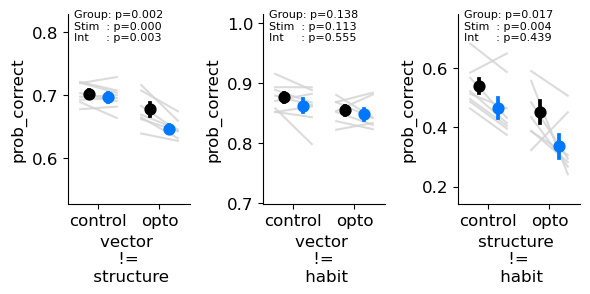

In [79]:
reload(psy)
strat_pairs = [("vector", "structure"), ("vector", "habit"), ("structure", "habit")]
fig, axes = plt.subplots(1, len(strat_pairs), figsize=(2 * len(strat_pairs), 3))
psy.plot_prop_optimal(navigation_strategies_df, strat_pairs=strat_pairs, axes=axes)
fig.tight_layout()
fig.savefig("../results/figures/habit_prop_optimal_summary.pdf")

### What do these excess steps represent when mFC is inhibited on difficult trials?
Let's model subjects navigation choices during light ON and light OFF as a mixture of 4 strategies:
- vector navigation
- structure based navigation (optimal)
- habitual actions (what you usually do given recent histroy regardless of the goal)
- a backtracking penalty (mice don't like to turn around while moving)

In [59]:
strategies = ["vector", "structure", "habit", "backtracking_penalty"]
results_df = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df,
    strategies=strategies,
    stim_day_range=(6, np.inf),
    max_trial_duration=None,
    stim_only=False,
)

Mixed ANOVA: vector
+-------------+-----------+-------+-------+-----------+----------+-----------+-----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |        F |     p-unc |       np2 |   eps |
|-------------+-----------+-------+-------+-----------+----------+-----------+-----------+-------|
| condition   | 0.104444  |     1 |    13 | 0.104444  | 4.51511  | 0.0533446 | 0.257784  |   nan |
| stim_trial  | 0.0280222 |     1 |    13 | 0.0280222 | 5.93448  | 0.0299869 | 0.313422  |     1 |
| Interaction | 0.0021256 |     1 |    13 | 0.0021256 | 0.450154 | 0.514006  | 0.0334683 |   nan |
+-------------+-----------+-------+-------+-----------+----------+-----------+-----------+-------+
Mixed ANOVA: structure
+-------------+------------+-------+-------+------------+----------+------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |      p-unc |      np2 |   eps |
|-------------+------------+-------+-------+------------+-----

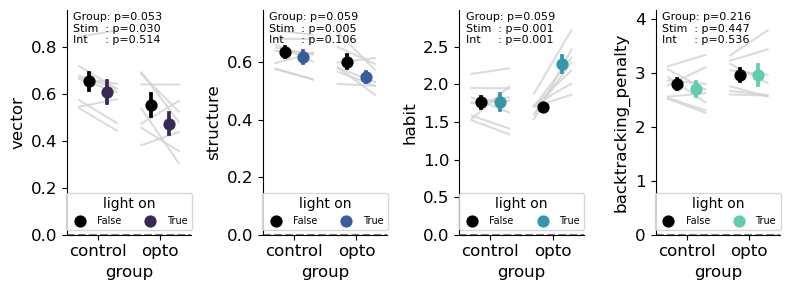

In [61]:
reload(oe)
fig, axes = plt.subplots(1, len(strategies), figsize=(2 * len(strategies), 3))
oe.plot_mixture_of_strategy_weights(results_df, axes=axes, cmap="mako")
fig.tight_layout()
fig.savefig("../results/figures/mixture_of_strategy_weights.pdf")

Mixed ANOVA: vector
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |     p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------|
| condition   | 0.0763974   |     1 |    13 | 0.0763974   | 3.42098  | 0.0872323 | 0.20833   |   nan |
| stim_trial  | 0.0202022   |     1 |    13 | 0.0202022   | 3.93227  | 0.0689045 | 0.232235  |     1 |
| Interaction | 0.000792292 |     1 |    13 | 0.000792292 | 0.154216 | 0.700902  | 0.0117237 |   nan |
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
Mixed ANOVA: structure_close
+-------------+-----------+-------+-------+-----------+----------+------------+----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |        F |      p-unc |      np2 |   eps |
|-------------+-----------+-----

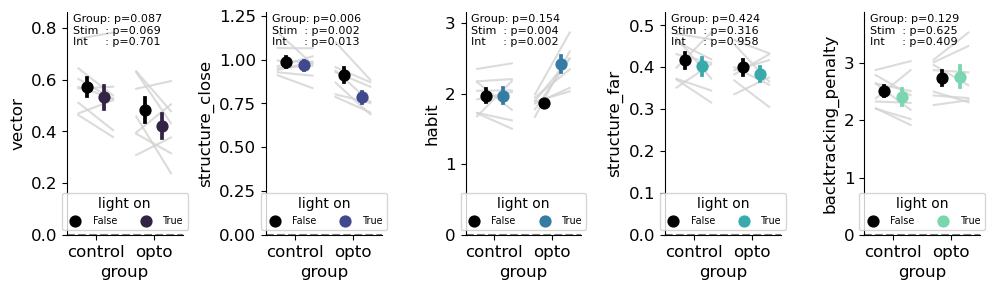

In [ ]:
# variant splitting structure into close and far strategies
strategies = ["vector", "structure_close", "habit", "structure_far", "backtracking_penalty"]
navigation_strategies_df = gid.get_navigation_strategies_df(strategies=strategies, close_far_cutoff=4)
results_df = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df,
    strategies=strategies,
    stim_day_range=(6, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(2 * len(strategies), 3))
oe.plot_mixture_of_strategy_weights(results_df, axes=axes, cmap="mako")
fig.tight_layout()

### basic controls checking for difference in movement speeds etc.

In [81]:
from GridMaze.analysis.behaviour import movement as mv

In [82]:
stim_on_df = mv.get_aligned_speeds_df(aligned_to="stim_on", verbose=False)
stim_off_df = mv.get_aligned_speeds_df(aligned_to="stim_off", verbose=False)

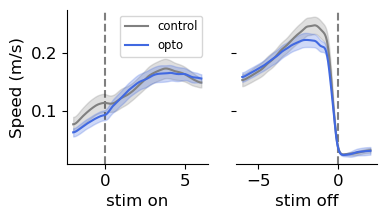

In [83]:
f, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
mv.plot_stim_aligned_speeds_summary(stim_on_df, stim_off_df, axes=axes)
f.savefig("../results/figures/maze_stim_aligned_speeds_summary.pdf")

In [84]:
reload(mv)
distance_traveled_df = mv.get_distance_traveled_df()

total_distance: t=2.41, p=0.0316
average_speed: t=-0.05, p=0.9578
stim_duration: t=1.01, p=0.3299


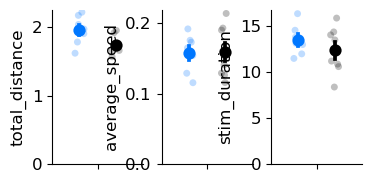

In [85]:
f, axes = plt.subplots(1, 3, figsize=(4, 2))
mv.plot_distance_travelled_summary(distance_traveled_df, axes=axes)
f.savefig("../results/figures/maze_distance_traveled_summary.pdf")

In [86]:
reload(mv)
stim_speeds_df = mv.get_stim_speeds_df()

Mixed ANOVA: average_speed
+-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |       F |     p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------|
| condition   | 0.00114144  |     1 |    13 | 0.00114144  | 0.49026 | 0.496152  | 0.0363418 |   nan |
| stim_trial  | 0.0002014   |     1 |    13 | 0.0002014   | 3.53786 | 0.0825694 | 0.213925  |     1 |
| Interaction | 0.000431709 |     1 |    13 | 0.000431709 | 7.58355 | 0.0164174 | 0.368428  |   nan |
+-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------+


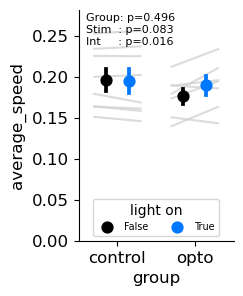

In [87]:
fig, ax = plt.subplots(1, 1, figsize=(2, 3))
mv.plot_stim_speeds_summary(stim_speeds_df, stim_day_range=(6, np.inf), ax=ax)
fig.savefig("../results/figures/maze_stim_speeds_summary.pdf")

### Anatomy

In [ ]:
from GridMaze.analysis.anatomy import blobs as ab

In [ ]:
opto_anatomy_df = ab.get_opto_anatomy_df(condition="opto", verbose=False)

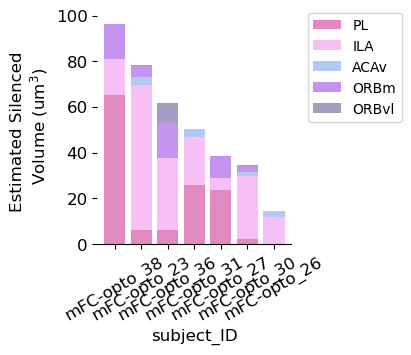

In [88]:
f, ax = plt.subplots(1, 1, figsize=(2.5, 3))
ab.plot_anatomy_summary(
    opto_anatomy_df,
    subject_order=[
        "mFC-opto_38",
        "mFC-opto_23",
        "mFC-opto_36",
        "mFC-opto_31",
        "mFC-opto_27",
        "mFC-opto_30",
        "mFC-opto_26",
    ],
    ax=ax,
)
f.savefig("../results/figures/opto_anatomy_summary.pdf")

In [65]:
from GridMaze.analysis.anatomy import corr_behaviour as cb

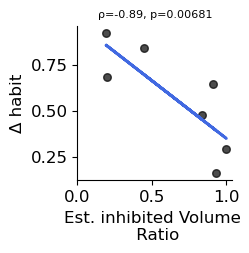

In [89]:
reload(cb)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
cb.plot_anat_corr_behaviour(
    behavioural_metric="delta_habit",
    regions=["ILA"],
    ratio=["PL", "ILA"],
    ax=ax,
)
fig.savefig("../results/figures/anat_corr_delta_habit.pdf")